##  A Comparative Study of Ridge and Lasso Regularization Based on MSE Performance on Real Estate Data

Simple example to understand how L1 (Lasso) and L2 (Ridge) regularization work in practice.

Scenario: Predicting House Prices
Imagine you have a dataset with the following features:
Size (sqft)	Bedrooms	Age (years)	Distance to city (km)	Noise Level	Price ($)

Let’s say you’re using linear regression to predict house prices based on these 4 features.
________________________________________
 Simple example to understand how L1 (Lasso) and L2 (Ridge) regularization work in practice.
Scenario: Predicting House Prices
Imagine you have a dataset with the following features:
Size (sqft)	Bedrooms	Age (years)	Distance to city (km)	Noise Level	Price ($)

Let’s say you’re using linear regression to predict house prices based on these 4 features.
________________________________________
 🔧 Step 1: The Problem Without Regularization
A linear model would look like this:

Price
=
𝑤
1
⋅
Size
+
𝑤
2
⋅
Bedrooms
+
𝑤
3
⋅
Age
+
𝑤
4
⋅
Distance
+
𝑤
5
⋅
Noise
+
𝑏
Price=w
1
​
 ⋅Size+w
2
​
 ⋅Bedrooms+w
3
​
 ⋅Age+w
4
​
 ⋅Distance+w
5
​
 ⋅Noise+b
When trained without regularization, the model might overfit — it memorizes the training data, including noise, and generalizes poorly to new data.
________________________________________
🧮 Step 2: L2 Regularization (Ridge)
Let’s say Ridge regression learns:
•	w1 = 250
•	w2 = 10000
•	w3 = -500
•	w4 = -3000
•	w5 = -50
Here, none of the weights are zero — Ridge shrinks them but keeps all features. Even less important features like “Noise Level” are kept with small weights.
✅ Good when all features have some relevance.
________________________________________
✂️ Step 3: L1 Regularization (Lasso)
Lasso regression might learn:
•	w1 = 300
•	w2 = 0
•	w3 = -600
•	w4 = -3500
•	w5 = 0
Here, some weights are exactly zero. Lasso eliminated "Bedrooms" and "Noise Level" — deciding they’re not useful for predicting price.
✅ Good when you want automatic feature selection.
________________________________________
💡 Intuition Recap
•	Ridge: "Keep all features, just shrink their impact."
•	Lasso: "Keep only the most important features; ignore the rest."


________________________________________
🧮 Step 2: L2 Regularization (Ridge)
Let’s say Ridge regression learns:
•	w1 = 250
•	w2 = 10000
•	w3 = -500
•	w4 = -3000
•	w5 = -50
Here, none of the weights are zero — Ridge shrinks them but keeps all features. Even less important features like “Noise Level” are kept with small weights.
✅ Good when all features have some relevance.
________________________________________
✂️ Step 3: L1 Regularization (Lasso)
Lasso regression might learn:
•	w1 = 300
•	w2 = 0
•	w3 = -600
•	w4 = -3500
•	w5 = 0
Here, some weights are exactly zero. Lasso eliminated "Bedrooms" and "Noise Level" — deciding they’re not useful for predicting price.
✅ Good when you want automatic feature selection.
________________________________________
💡 Intuition Recap
•	Ridge: "Keep all features, just shrink their impact."
•	Lasso: "Keep only the most important features; ignore the rest."



With out Regulation

In [28]:
import pandas as pd

In [29]:
# Load the dataset
data = pd.read_csv("house_data.csv")

In [44]:
data

,Size,Bedrooms,Age,Distance,Noise,Price
0,2100,3,20,10,3,500000
1,1600,2,15,8,4,350000
2,2400,4,30,12,2,550000
3,1400,2,10,7,5,280000
4,3000,4,8,15,1,620000
5,1800,3,25,9,3,400000
6,2200,3,18,11,2,510000
7,1700,2,5,6,4,330000
8,2500,4,12,13,2,560000
9,1900,3,22,9,3,420000


In [30]:
data.columns

Index(['Size', 'Bedrooms', 'Age', 'Distance', 'Noise', 'Price'], dtype='object')

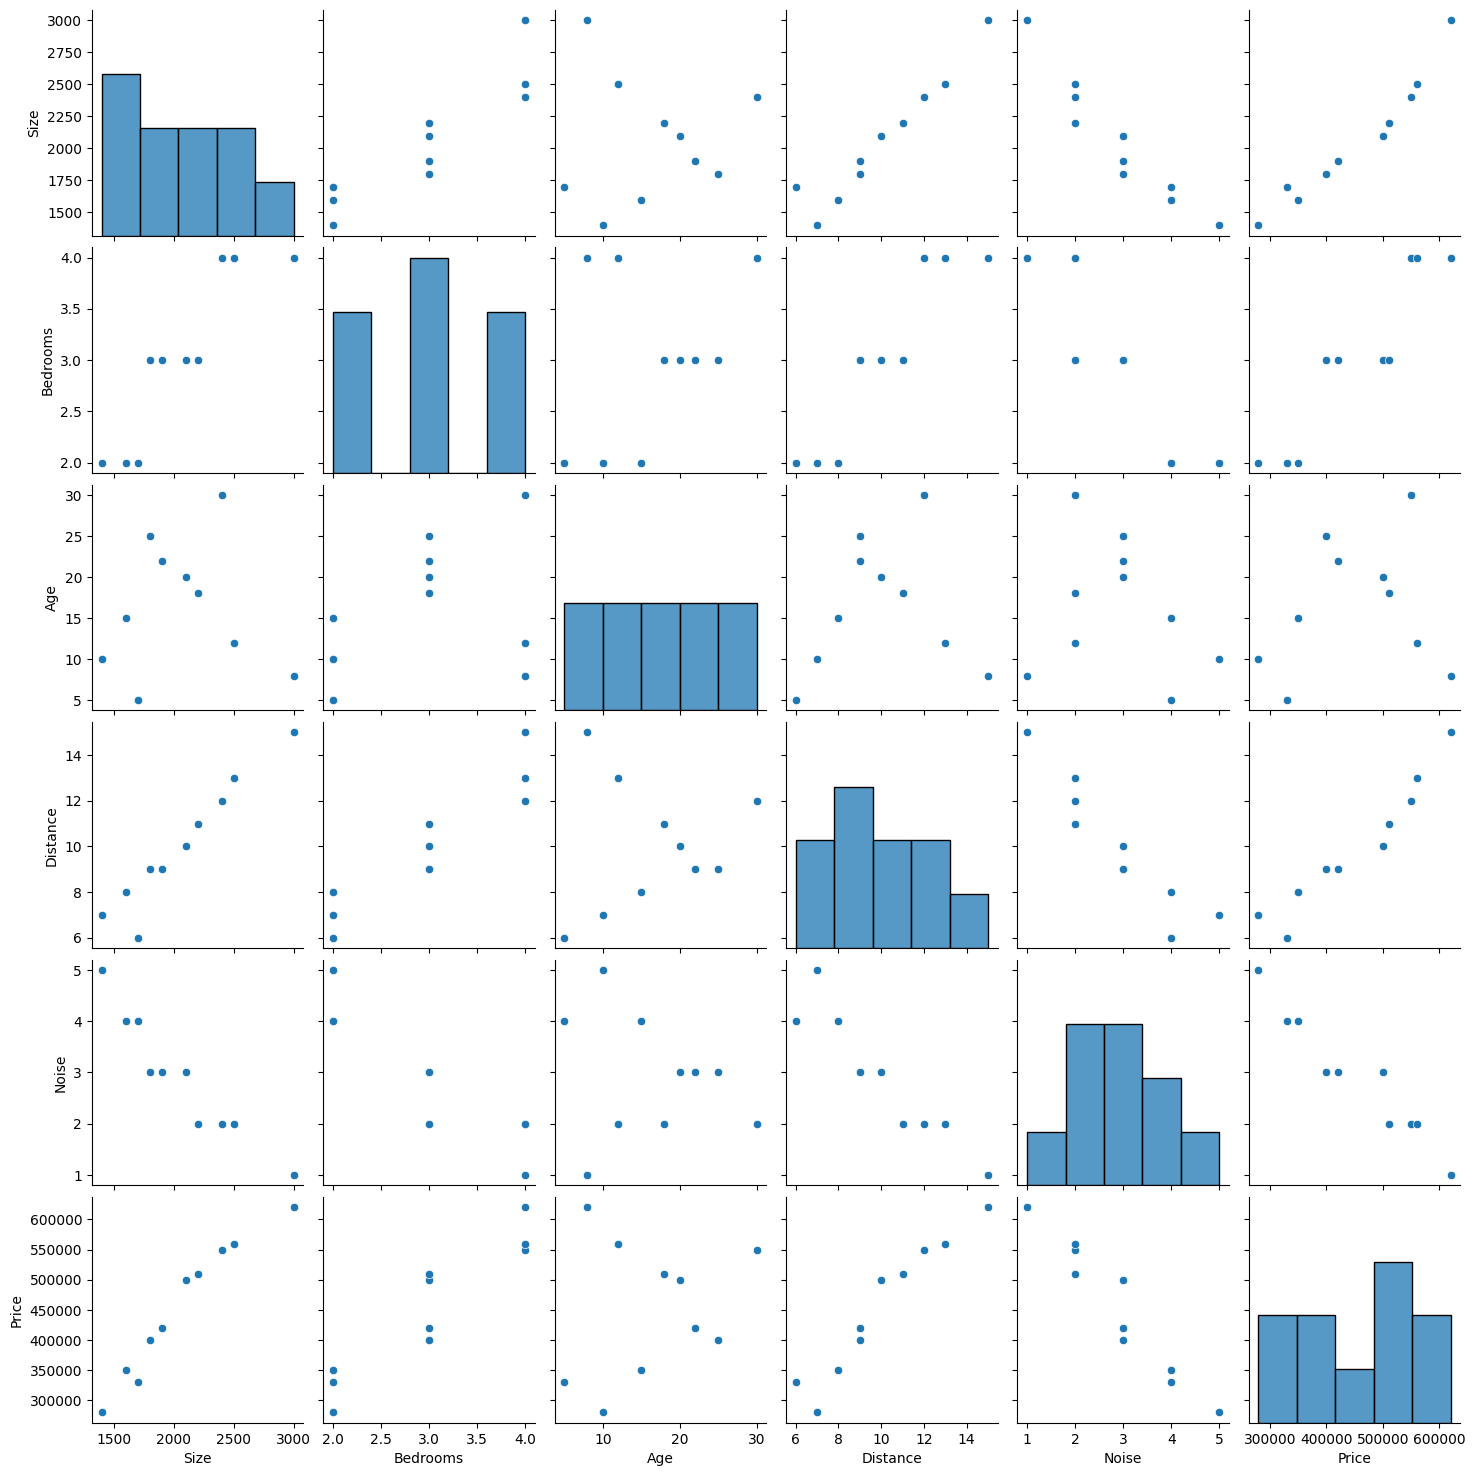

In [31]:
import seaborn as sn
sn.pairplot(data)

In [32]:

# Features and target
X = data[["Size", "Bedrooms", "Age", "Distance", "Noise"]]
y = data["Price"]

In [33]:
# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
# Linear Regression (no regularization)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [35]:
print("Linear Regression Coefficients:", lr.coef_)

Linear Regression Coefficients: [    444.61281151 -173441.04365278    9495.56782071   11357.75213246
   24375.31359759]


In [36]:
from sklearn.metrics import mean_squared_error
y_pred = lr.predict(X_test)
mse_No_regulation = mean_squared_error(y_test, y_pred)
mse_No_regulation

6030552235.867668

L1 Regulation

In [37]:
# Linear Regression (L1 regularization)
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=10000)

lasso.fit(X_train, y_train)

Lasso(alpha=10000)

In [38]:
print("Lasso Coefficients:", lasso.coef_)

Lasso Coefficients: [ 217.44393553   -0.         3047.82636731    0.           -0.        ]


In [39]:
from sklearn.metrics import mean_squared_error
y_pred = lasso.predict(X_test)
mse_L1_regulation = mean_squared_error(y_test, y_pred)
mse_L1_regulation

386616266.9086984

L2 Regulation Ridge

In [40]:
# Linear Regression (L2 regularization)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [41]:
print("Lasso Coefficients:", ridge.coef_)

Lasso Coefficients: [   203.32504237 -11135.44373757   3333.70577304   2628.81163418
  -5758.50426248]


In [42]:
from sklearn.metrics import mean_squared_error
y_pred = ridge.predict(X_test)
mse_L2_regulation = mean_squared_error(y_test, y_pred)
mse_L2_regulation

534449340.9176319

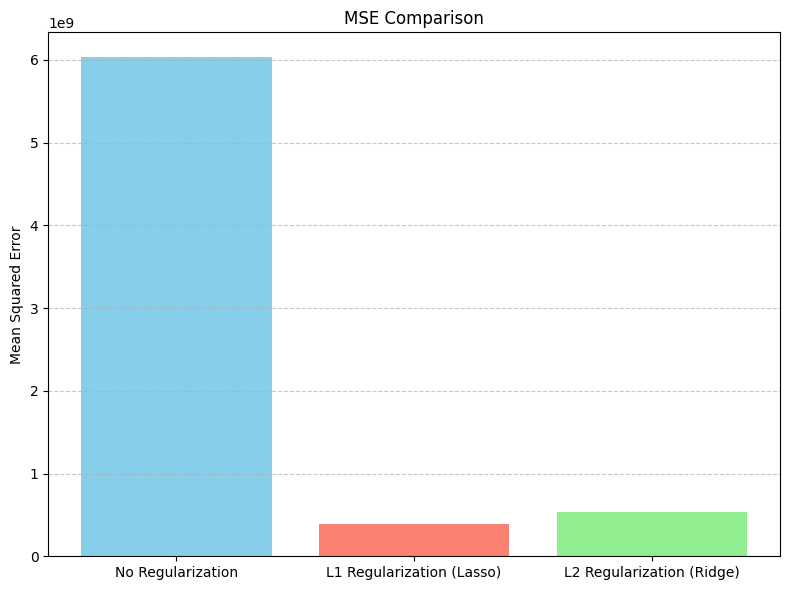

In [43]:
import matplotlib.pyplot as plt

mse_values = {
    "No Regularization": mse_No_regulation,
    "L1 Regularization (Lasso)": mse_L1_regulation,
    "L2 Regularization (Ridge)": mse_L2_regulation
}

plt.figure(figsize=(8, 6))
plt.bar(mse_values.keys(), mse_values.values(), color=["skyblue", "salmon", "lightgreen"])
plt.title("MSE Comparison")
plt.ylabel("Mean Squared Error")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
